# EDA SVCASC — Datos de Calidad del Aire y Meteorologia
---
**Proyecto:** GeoVision-CLIP Cali  
**Fuente:** SVCASC.FT.50 — Sistema de Vigilancia de Calidad el Aire de Santiago de Cali  
**Periodo:** 2020-01-01 a 2023-12-31 (4 anos)  
**Estaciones:** 9 estaciones de monitoreo en Cali y area metropolitana  
**Variables:** NO2, O3, SO2, PM25, PM10, H2S, temperatura, humedad, viento, lluvia, radiacion solar, presion

### Contexto
Los datos provienen del sistema SVCASC (Sistema de Vigilancia de Calidad del Aire de Santiago de Cali).
Son datos generados por modelos de prediccion (no mediciones en tiempo real directas), utiles para
analizar patrones estacionales, ciclos diurnos y relaciones entre contaminantes y meteorologia.

### Nota sobre NO2
NO2 solo tiene registros en la estacion Univalle (~69% cobertura). Las demas estaciones no reportan NO2.
Para el proyecto GeoVision-CLIP, esto significa que el ground truth de NO2 es limitado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import Fullscreen
from pathlib import Path
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (14, 5),
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10
})
print('Librerias OK')

Librerias OK


In [3]:
# Cargar datos
df = pd.read_csv('DAGMAdatos.csv', parse_dates=['Fecha_Hora'])
df = df.sort_values('Fecha_Hora').reset_index(drop=True)

print(f'Filas: {len(df):,}')
print(f'Columnas: {len(df.columns)}')
print(f'Periodo: {df["Fecha_Hora"].min()} a {df["Fecha_Hora"].max()}')
print(f'Rango horario: {df["Fecha_Hora"].dt.hour.unique().min()}:00 a {df["Fecha_Hora"].dt.hour.unique().max()}:00')

# Crear columnas auxiliares
df['year'] = df['Fecha_Hora'].dt.year
df['month'] = df['Fecha_Hora'].dt.month
df['hour'] = df['Fecha_Hora'].dt.hour
df['date'] = df['Fecha_Hora'].dt.date
df['month_str'] = df['Fecha_Hora'].dt.strftime('%Y-%m')

df.head(3)

Filas: 33,580
Columnas: 87
Periodo: 2020-01-01 01:00:00 a 2023-12-30 23:00:00
Rango horario: 1:00 a 23:00


,Fecha_Hora,Base_Aerea_PM25,Canaveralejo_PM25,Compartir_PM25,ERA_-_Obrero_PM25,Ermita_PM25,Flora_PM25,Pance_PM25,Transitoria_-_Navarro_PM25,Univalle_PM25,...,ERA_-_Obrero_Presion_Baromet,Flora_Presion_Baromet,Pance_Presion_Baromet,Transitoria_-_Navarro_Presion_Baromet,Univalle_Presion_Baromet,year,month,hour,date,month_str
0,2020-01-01 01:00:00,158.0,NaN,121.0,NaN,NaN,NaN,NaN,NaN,42.0,...,NaN,NaN,NaN,NaN,NaN,2020,1,1,2020-01-01,2020-01
1,2020-01-01 02:00:00,51.0,NaN,36.0,NaN,NaN,NaN,NaN,NaN,52.0,...,NaN,NaN,NaN,NaN,NaN,2020,1,2,2020-01-01,2020-01
2,2020-01-01 03:00:00,44.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,38.0,...,NaN,NaN,NaN,NaN,NaN,2020,1,3,2020-01-01,2020-01


---
## 1. Cobertura de datos — Mapa de calor
Identificamos que estaciones y variables tienen datos y donde hay huecos.

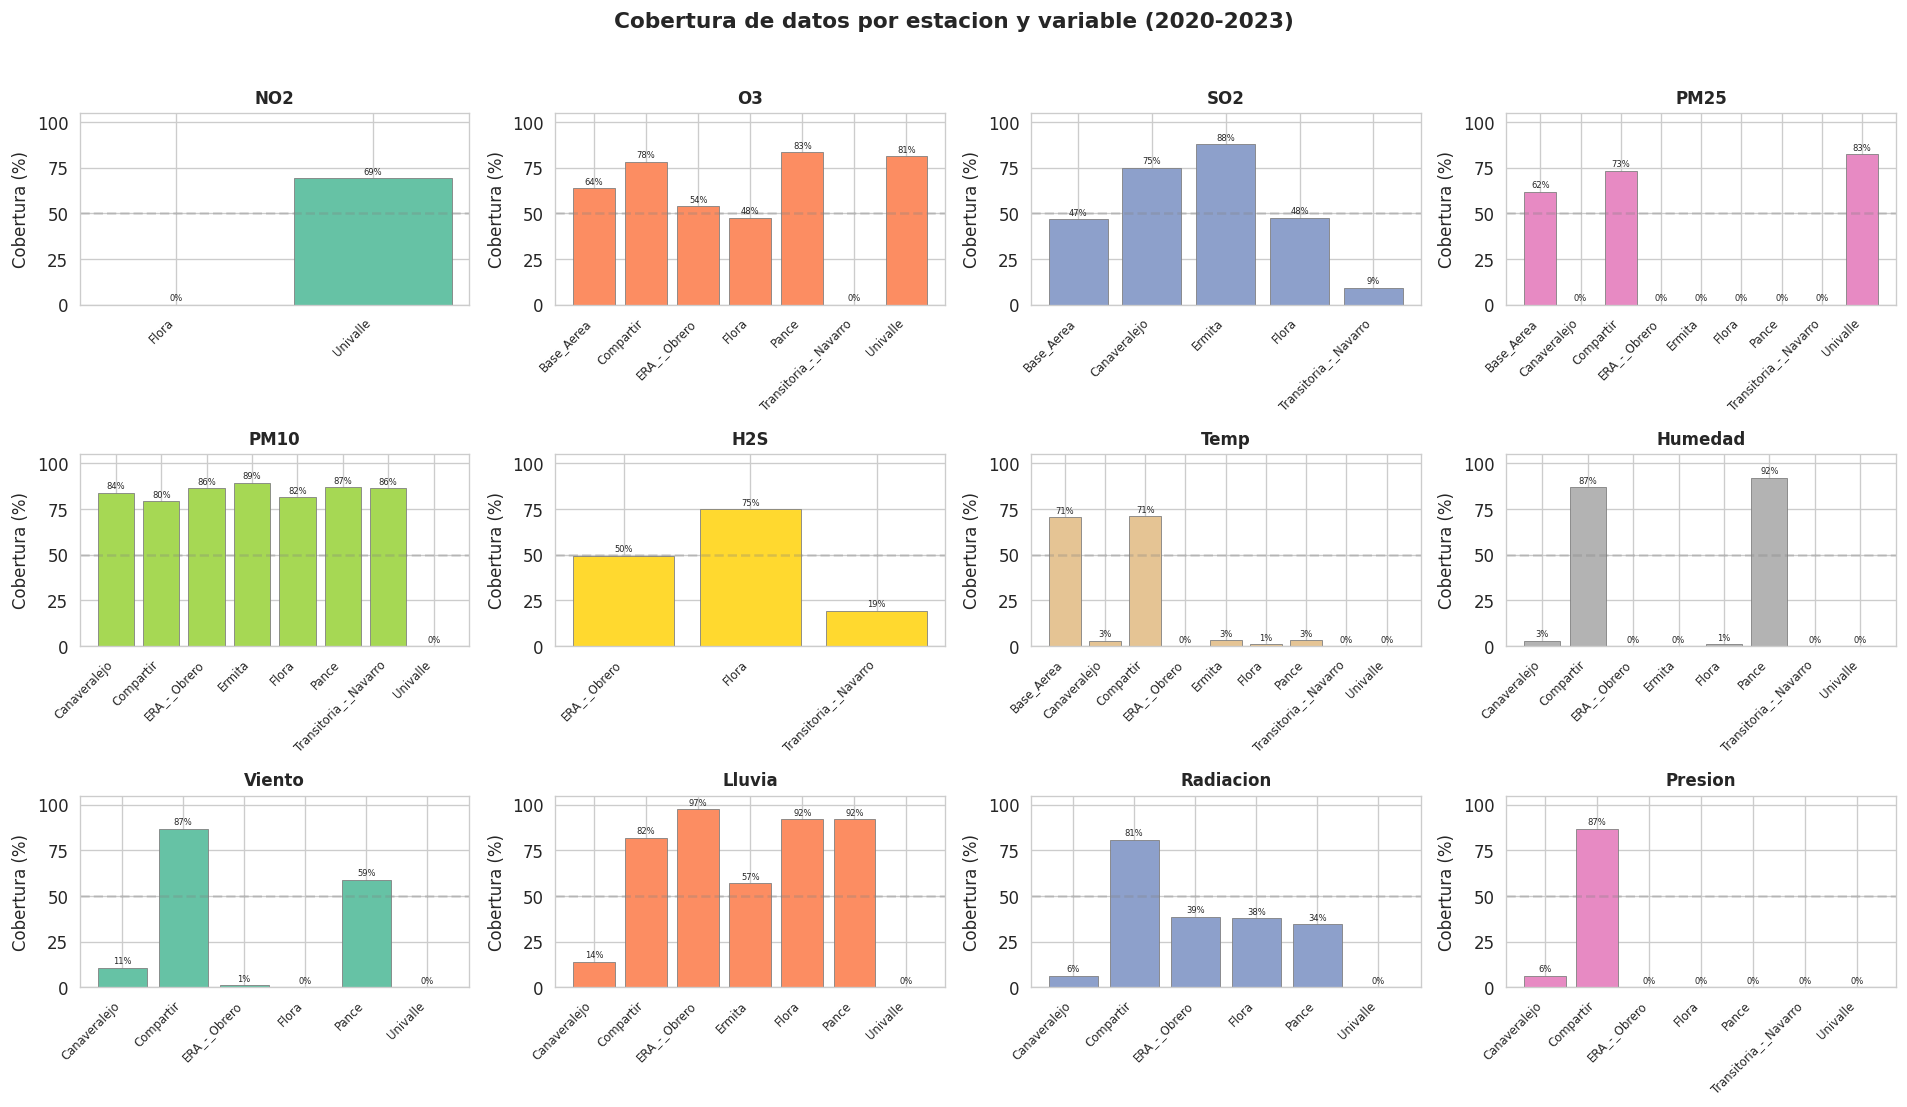

In [4]:
# Variables conocidas (ordenadas de mas especifica a menos)
KNOWN_VARS = [
    'Presion_Baromet', 'Radiacion_Solar', 'Vel_Viento', 'Dir_Viento',
    'Black_Carbon', 'UV-PM',
    'Temperatura', 'Humedad', 'Lluvia',
    'PM25', 'PM10', 'NO2', 'SO2', 'O3', 'H2S',
]

def extraer_estacion(col_name):
    """Extrae el nombre de la estacion"""
    for var in KNOWN_VARS:
        suffix = '_' + var
        if col_name.endswith(suffix):
            return col_name[:-len(suffix)]
    return col_name.rsplit('_', 1)[0]

def extraer_variable(col_name):
    """Extrae el nombre de la variable"""
    for var in KNOWN_VARS:
        suffix = '_' + var
        if col_name.endswith(suffix):
            return var
    return col_name.rsplit('_', 1)[-1]

# Agrupar columnas por variable
var_groups = {
    'NO2': [c for c in df.columns if extraer_variable(c) == 'NO2'],
    'O3': [c for c in df.columns if extraer_variable(c) == 'O3'],
    'SO2': [c for c in df.columns if extraer_variable(c) == 'SO2'],
    'PM25': [c for c in df.columns if extraer_variable(c) == 'PM25'],
    'PM10': [c for c in df.columns if extraer_variable(c) == 'PM10'],
    'H2S': [c for c in df.columns if extraer_variable(c) == 'H2S'],
    'Temp': [c for c in df.columns if extraer_variable(c) == 'Temperatura'],
    'Humedad': [c for c in df.columns if extraer_variable(c) == 'Humedad'],
    'Viento': [c for c in df.columns if extraer_variable(c) in ('Vel_Viento', 'Dir_Viento')],
    'Lluvia': [c for c in df.columns if extraer_variable(c) == 'Lluvia'],
    'Radiacion': [c for c in df.columns if extraer_variable(c) == 'Radiacion_Solar'],
    'Presion': [c for c in df.columns if extraer_variable(c) == 'Presion_Baromet'],
}

# Calcular cobertura para cada estacion y variable
cov_data = {}
for grupo, cols in var_groups.items():
    for c in cols:
        station = extraer_estacion(c)
        coverage = df[c].notna().mean() * 100
        if grupo not in cov_data:
            cov_data[grupo] = {}
        cov_data[grupo][station] = coverage

# Subplots: uno por variable, estaciones en eje X, cobertura en Y
grupos_vis = [g for g in var_groups if g in cov_data]
n_cols = 4
n_rows = (len(grupos_vis) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()
colors = plt.cm.Set2.colors

for idx, grupo in enumerate(grupos_vis):
    ax = axes[idx]
    stations = sorted(cov_data[grupo].keys())
    values = [cov_data[grupo][s] for s in stations]
    ax.bar(range(len(stations)), values, color=colors[idx % len(colors)], edgecolor='gray', linewidth=0.5)
    ax.set_xticks(range(len(stations)))
    ax.set_xticklabels(stations, rotation=45, ha='right', fontsize=7)
    ax.set_ylim(0, 105)
    ax.set_ylabel('Cobertura (%)')
    ax.set_title(grupo, fontsize=10, weight='bold')
    ax.axhline(50, color='gray', linestyle='--', alpha=0.3)
    for i, v in enumerate(values):
        ax.text(i, v + 1, f'{v:.0f}%', ha='center', va='bottom', fontsize=5)

# Ocultar subplots sobrantes
for idx in range(len(grupos_vis), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Cobertura de datos por estacion y variable (2020-2023)', fontsize=13, weight='bold', y=1.02)
plt.tight_layout()
plt.show()



### Interpretacion de cobertura

- **Variables con mejor cobertura (>80%):** PM10 (varias estaciones), Lluvia (ERA-Obrero, Flora, Pance), Presion (Compartir), Humedad (Pance), O3 (Pance, Univalle, Compartir), SO2 (Ermita), PM25 (Univalle).
- **Variables con cobertura media (50-80%):** NO2 (Univalle, 69%), O3 y SO2 en varias estaciones, Radiacion Solar.
- **Variables con baja cobertura (<50%):** NO2 solo en Univalle (Flora 0%), Black Carbon, UV-PM, varias estaciones de temperatura/humedad/viento.
- **Implicacion:** El analisis conjunto de multiples variables requiere cuidado porque las estaciones con datos no siempre coinciden.

---
## 2. Series temporales mensuales
Promedio mensual de contaminantes y variables meteorologicas en toda la red.

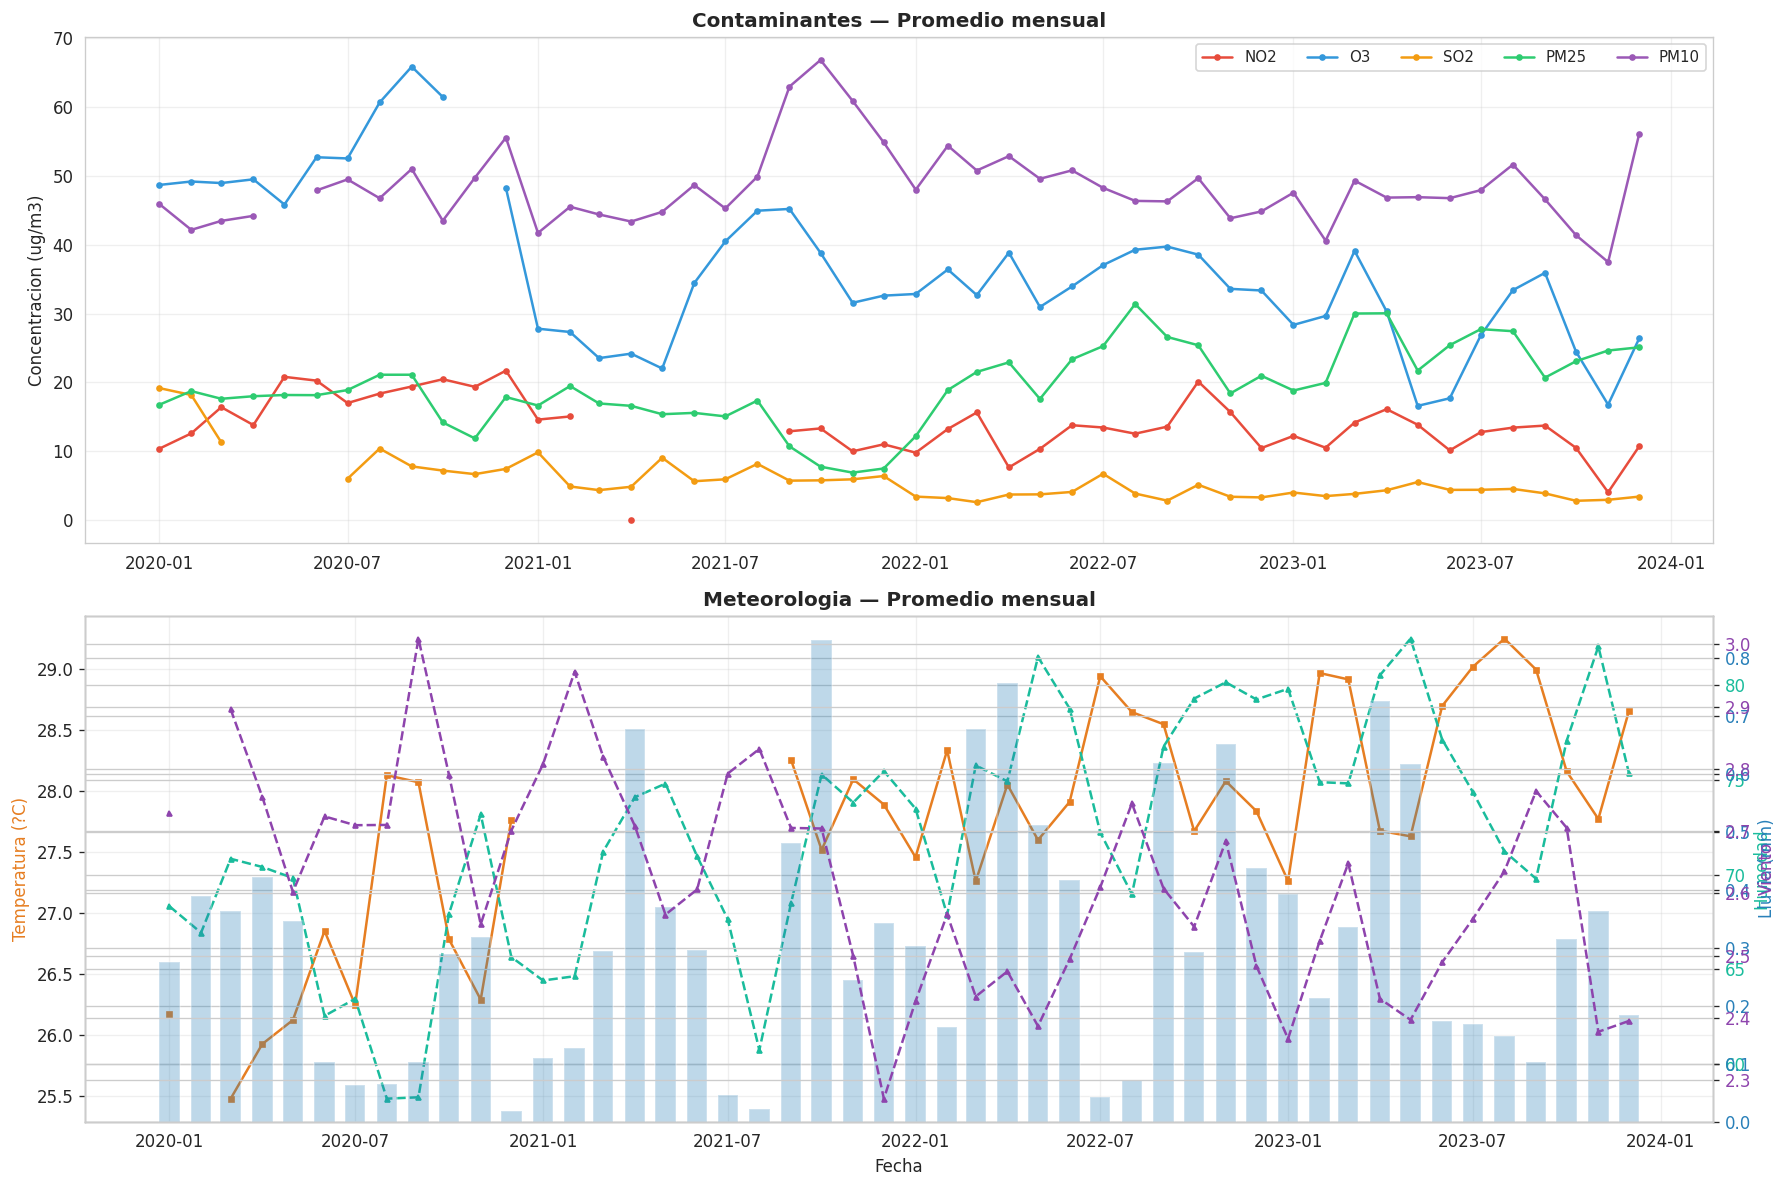

In [5]:
# Definir variables clave para series temporales
pollutants = {
    'NO2': 'Univalle_NO2',
    'O3': 'Pance_O3',
    'SO2': 'Ermita_SO2',
    'PM25': 'Univalle_PM25',
    'PM10': 'Ermita_PM10',
}
meteo_vars = {
    'Temperatura': 'Compartir_Temperatura',
    'Humedad': 'Pance_Humedad',
    'Lluvia': 'ERA_-_Obrero_Lluvia',
    'Viento': 'Compartir_Vel_Viento',
}

# Agregacion mensual
monthly = df.groupby(['year', 'month']).agg({
    **{v: 'mean' for v in pollutants.values()},
    **{v: 'mean' for v in meteo_vars.values()}
}).reset_index()
monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))
monthly = monthly.sort_values('date')

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Panel 1: Contaminantes
ax = axes[0]
colors_poll = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71', '#9b59b6']
for (name, col), color in zip(pollutants.items(), colors_poll):
    ax.plot(monthly['date'], monthly[col], color=color, linewidth=1.5,
            marker='o', markersize=3, label=name)
ax.set_ylabel('Concentracion (ug/m3)')
ax.set_title('Contaminantes — Promedio mensual', fontsize=12, weight='bold')
ax.legend(ncol=5, fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 2: Meteorologia
ax = axes[1]
colors_met = ['#e67e22', '#1abc9c', '#2980b9', '#8e44ad']
for (name, col), color in zip(meteo_vars.items(), colors_met):
    ax2 = ax.twinx() if name != 'Temperatura' else ax
    if name == 'Temperatura':
        ax.plot(monthly['date'], monthly[col], color=color, linewidth=1.5,
                marker='s', markersize=3, label=name)
        ax.set_ylabel('Temperatura (?C)', color=color)
    elif name == 'Lluvia':
        ax2.bar(monthly['date'], monthly[col], alpha=0.3, color=color,
                width=20, label=name)
        ax2.set_ylabel('Lluvia (mm)', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
    else:
        ax2.plot(monthly['date'], monthly[col], color=color, linewidth=1.5,
                marker='^', markersize=3, label=name, linestyle='--')
        ax2.set_ylabel(f'{name}', color=color)
        ax2.tick_params(axis='y', labelcolor=color)

ax.set_title('Meteorologia — Promedio mensual', fontsize=12, weight='bold')
ax.set_xlabel('Fecha')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretacion de series temporales

- **NO2 (Univalle, ~14 ug/m3):** Valores relativamente estables, con ligeros descensos en 2020 (posible efecto COVID-19) y recuperacion en 2021-2023.
- **O3 (Pance, ~20-60 ug/m3):** Ciclo estacional marcado con picos en meses de mayor radiacion solar (mitad de ano).
- **SO2 (Ermita, ~5-10 ug/m3):** Estable, sin grandes variaciones interanuales.
- **PM25 y PM10:** Muestran variabilidad estacional con picos en periodos secos.
- **Temperatura:** Sigue el ciclo esperado (~24-28?C), correlacionada positivamente con O3.
- **Lluvia:** Concentrada en meses de mayor precipitacion (abril-mayo y octubre-noviembre), con 2020 y 2022 mas secos.

---
## 3. Estacionalidad — Boxplots mensuales
Variabilidad interanual de cada contaminante por mes.

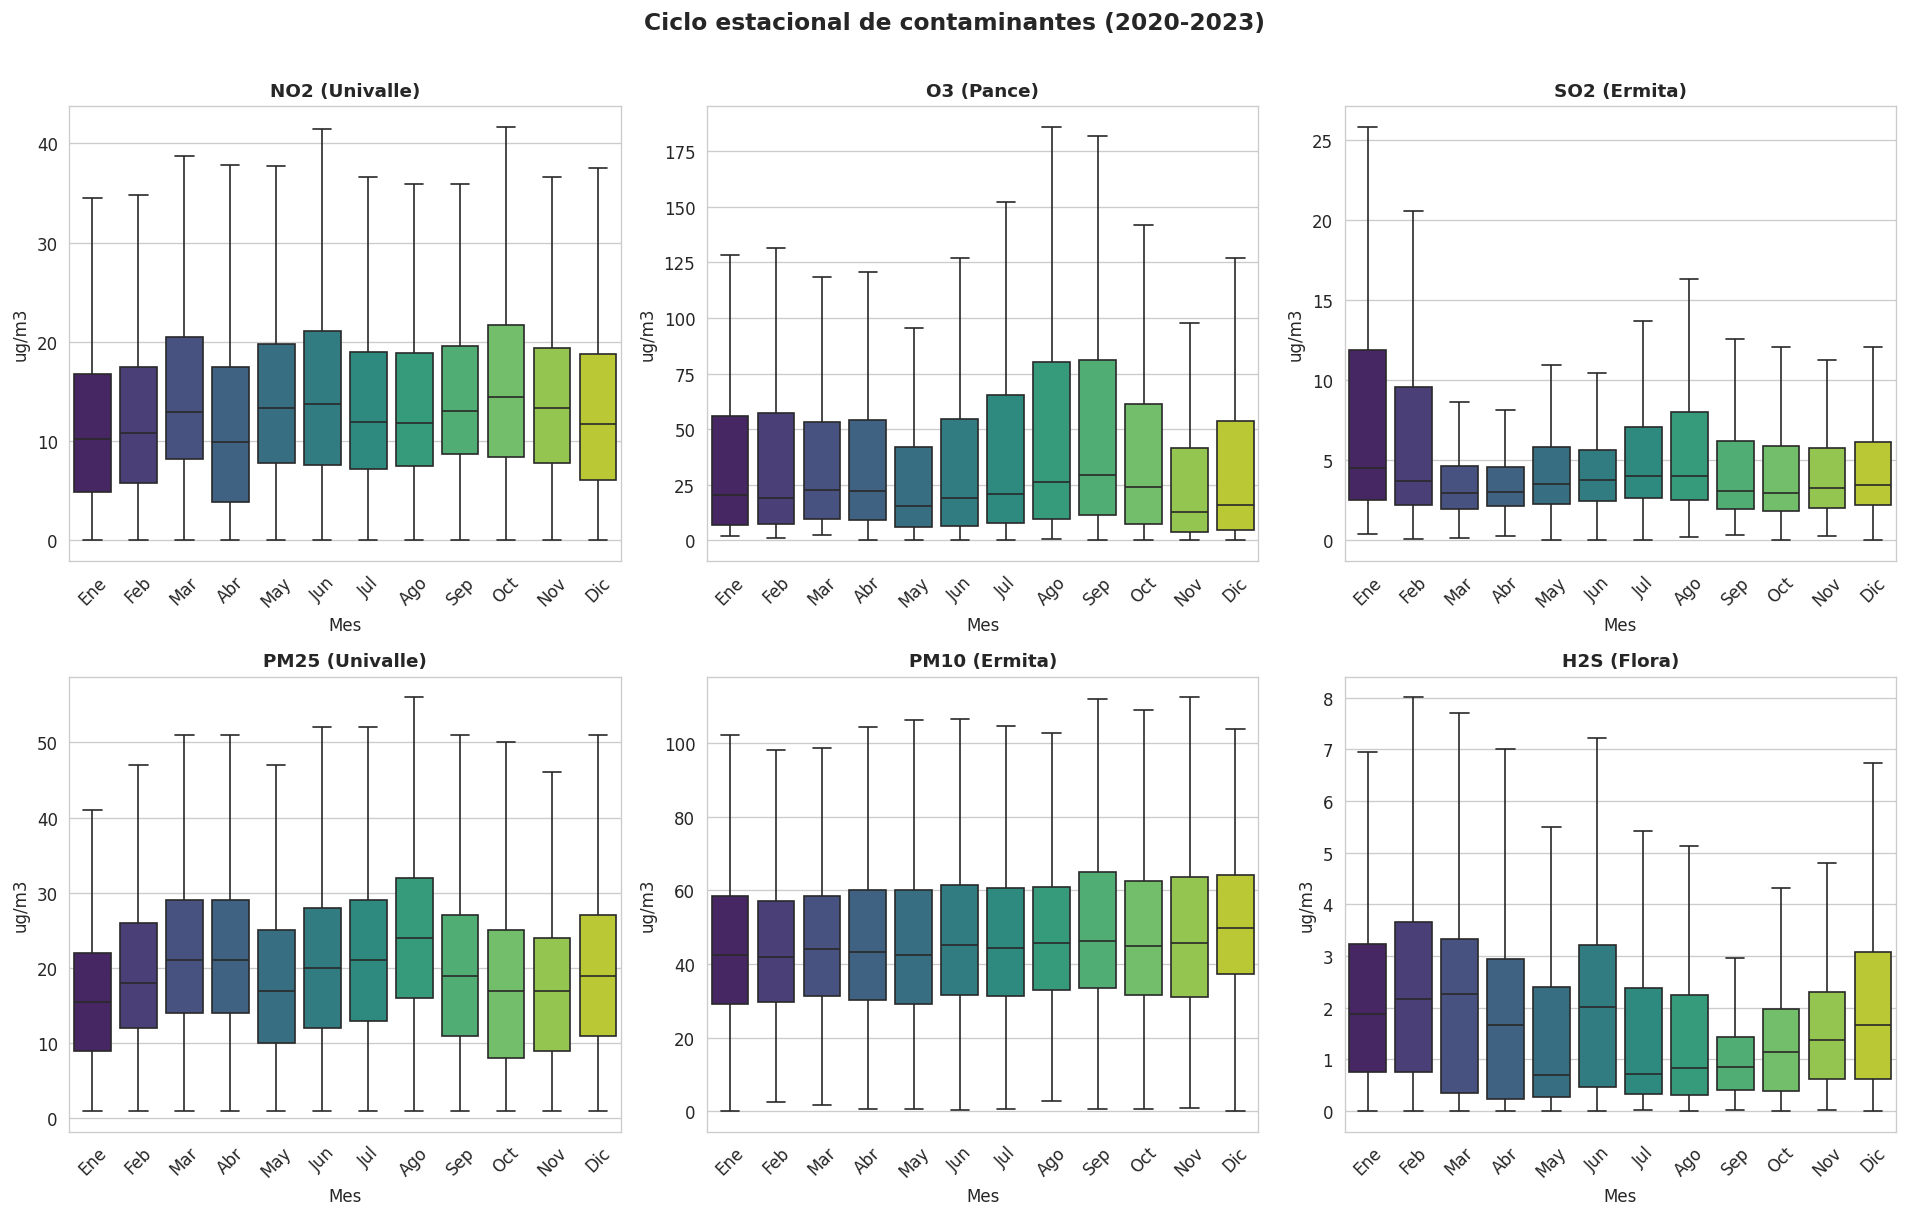

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

pollutants_box = {
    'NO2 (Univalle)': 'Univalle_NO2',
    'O3 (Pance)': 'Pance_O3',
    'SO2 (Ermita)': 'Ermita_SO2',
    'PM25 (Univalle)': 'Univalle_PM25',
    'PM10 (Ermita)': 'Ermita_PM10',
    'H2S (Flora)': 'Flora_H2S',
}

for ax, (label, col) in zip(axes, pollutants_box.items()):
    data = df[['month', col]].dropna()
    sns.boxplot(x='month', y=col, data=data, ax=ax, palette='viridis',
                showfliers=False)
    ax.set_title(label, fontsize=11, weight='bold')
    ax.set_xlabel('Mes')
    ax.set_ylabel('ug/m3')
    ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                        'Jul','Ago','Sep','Oct','Nov','Dic'], rotation=45)

plt.suptitle('Ciclo estacional de contaminantes (2020-2023)', fontsize=14, weight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Interpretacion del ciclo estacional
- **NO2:** Menor variabilidad en meses de lluvia (abril-mayo, octubre-noviembre) por mayor dispersion atmosferica.
- **O3:** Pico claro entre junio y agosto cuando la radiacion solar es maxima.
- **SO2:** Relativamente plano, con leve aumento en diciembre-enero (epoca seca).
- **PM25 y PM10:** Mayor concentracion en meses secos (diciembre-marzo), menor en lluvias.
- **H2S:** Mayor variabilidad en meses secos, probablemente por acumulacion de emisiones.

---
## 4. Ciclo diurno
Comportamiento promedio de contaminantes y meteorologia a lo largo del dia.

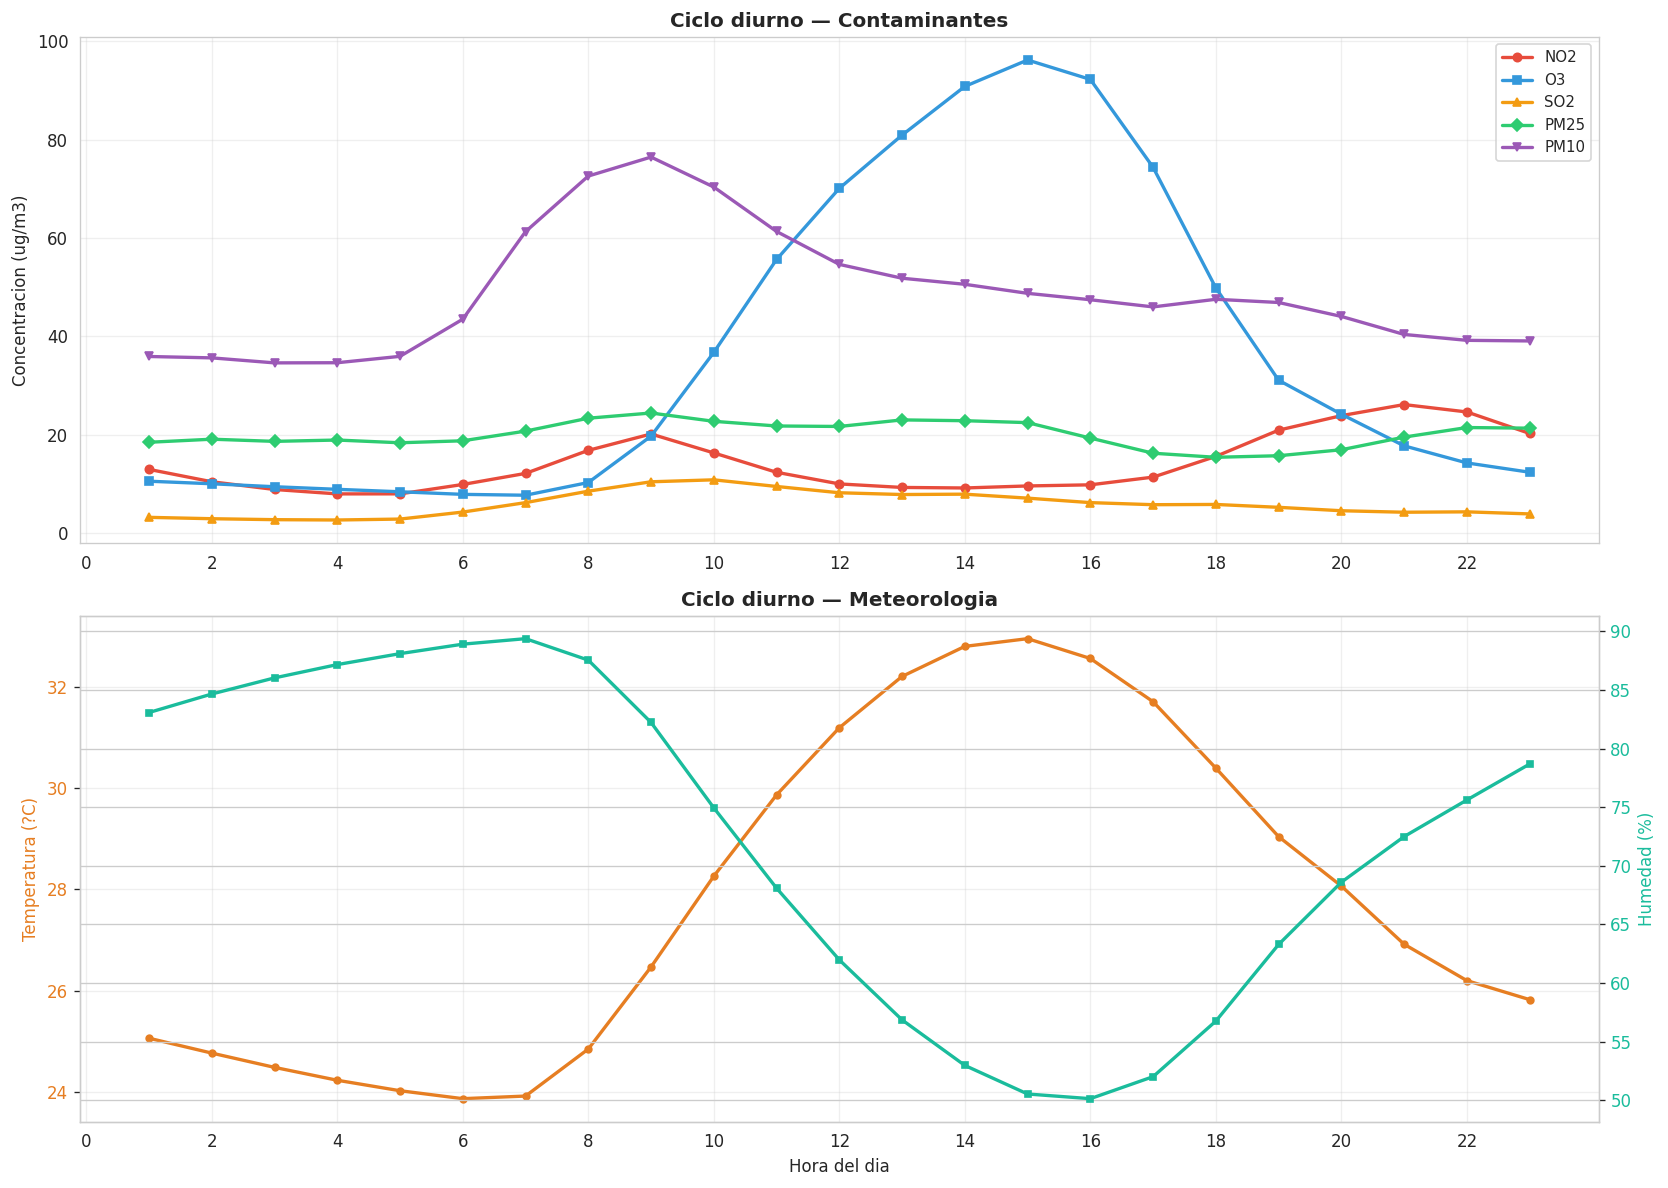

In [7]:
hourly = df.groupby('hour').agg({
    'Univalle_NO2': 'mean',
    'Pance_O3': 'mean',
    'Ermita_SO2': 'mean',
    'Univalle_PM25': 'mean',
    'Ermita_PM10': 'mean',
    'Compartir_Temperatura': 'mean',
    'Pance_Humedad': 'mean',
    'Compartir_Vel_Viento': 'mean',
})

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Panel contaminantes
ax = axes[0]
for col, color, marker in zip(
    ['Univalle_NO2', 'Pance_O3', 'Ermita_SO2', 'Univalle_PM25', 'Ermita_PM10'],
    ['#e74c3c', '#3498db', '#f39c12', '#2ecc71', '#9b59b6'],
    ['o', 's', '^', 'D', 'v']):
    label = col.split('_')[1] if '_' in col else col
    ax.plot(hourly.index, hourly[col], color=color, marker=marker,
            linewidth=2, markersize=5, label=label)
ax.set_ylabel('Concentracion (ug/m3)')
ax.set_title('Ciclo diurno — Contaminantes', fontsize=12, weight='bold')
ax.legend(fontsize=9)
ax.set_xticks(range(0, 24, 2))
ax.grid(True, alpha=0.3)

# Panel meteo
ax = axes[1]
ax.plot(hourly.index, hourly['Compartir_Temperatura'], color='#e67e22',
        linewidth=2, marker='o', markersize=4, label='Temperatura (?C)')
ax.set_ylabel('Temperatura (?C)', color='#e67e22')
ax.tick_params(axis='y', labelcolor='#e67e22')

ax2 = ax.twinx()
ax2.plot(hourly.index, hourly['Pance_Humedad'], color='#1abc9c',
         linewidth=2, marker='s', markersize=4, label='Humedad (%)')
ax2.set_ylabel('Humedad (%)', color='#1abc9c')
ax2.tick_params(axis='y', labelcolor='#1abc9c')

ax.set_title('Ciclo diurno — Meteorologia', fontsize=12, weight='bold')
ax.set_xlabel('Hora del dia')
ax.set_xticks(range(0, 24, 2))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretacion del ciclo diurno

- **NO2:** Doble pico en horas pico de trafico (7-9 AM y 7-9 PM), con minimo al mediodia por dispersion y menor actividad.
- **O3:** Maximo al mediodia por fotoquimica, minimo en la noche por consumo con NO.
- **SO2 y PM:** Patron relativamente plano con leve aumento diurno por actividad industrial.
- **Temperatura:** Maximo ~2-3 PM, minimo al amanecer. Anticorrelacion con humedad.

---
## 5. Mapa de estaciones SVCASC
Ubicacion de las 9 estaciones de monitoreo con radios proporcionales a NO2.

In [8]:
# Coordenadas de estaciones SVCASC (del Excel metadata)
estaciones = {
    'Base Aerea':       (3.4646, -76.5142),
    'Canaveralejo':     (3.4189, -76.5417),
    'Compartir':        (3.4306, -76.4764),
    'ERA Obrero':       (3.4537, -76.5208),
    'La Ermita':        (3.4515, -76.5322),
    'La Flora':         (3.4918, -76.5142),
    'Pance':            (3.3278, -76.5486),
    'Transitoria Navarro': (3.4789, -76.4892),
    'Univalle':         (3.3779, -76.5338),
}

m = folium.Map(location=[3.45, -76.50], tiles='OpenStreetMap',
               control_scale=True, zoom_start=11)
Fullscreen().add_to(m)

# BBox del proyecto
folium.Rectangle(
    bounds=[[3.30, -76.65], [3.65, -76.30]],
    color='black', weight=2, fill=False, dash_array='10, 5',
    popup='BBox Proyecto',
    tooltip='[-76.65, 3.30] a [-76.30, 3.65]'
).add_to(m)

# Calcular NO2 promedio por estacion
no2_means = {}
station_cols = {
    'Base Aerea': None, 'Canaveralejo': None, 'Compartir': None,
    'ERA Obrero': None, 'La Ermita': None, 'La Flora': 'Flora_NO2',
    'Pance': None, 'Transitoria Navarro': None, 'Univalle': 'Univalle_NO2'
}
for nombre, col in station_cols.items():
    if col and col in df.columns:
        no2_means[nombre] = df[col].mean()
    else:
        no2_means[nombre] = None

for nombre, (lat, lon) in estaciones.items():
    no2_val = no2_means.get(nombre)
    if no2_val and not np.isnan(no2_val):
        radius = float(np.clip(no2_val * 1.2, 6, 25))
        popup_html = f'<b>{nombre}</b><br>NO2: {no2_val:.1f} ug/m3'
        color = '#e74c3c'
    else:
        radius = 8
        popup_html = f'<b>{nombre}</b><br>Sin datos NO2'
        color = '#95a5a6'
    folium.CircleMarker(
        location=[lat, lon], radius=radius, color='black', weight=1.5,
        fill=True, fill_color=color, fill_opacity=0.8,
        popup=folium.Popup(popup_html, max_width=200),
        tooltip=nombre
    ).add_to(m)

m.fit_bounds([[3.30, -76.65], [3.65, -76.30]])
m.save('svcasc_mapa_estaciones.html')
print('Mapa guardado: svcasc_mapa_estaciones.html')
m






Mapa guardado: svcasc_mapa_estaciones.html


> El rectangulo punteado delimita el BBox del proyecto. Los circulos rojos son estaciones con datos de NO2,
> los grises no tienen NO2. El radio del circulo es proporcional a la concentracion media.

---
## 6. Matriz de correlacion
Relaciones entre contaminantes y variables meteorologicas.

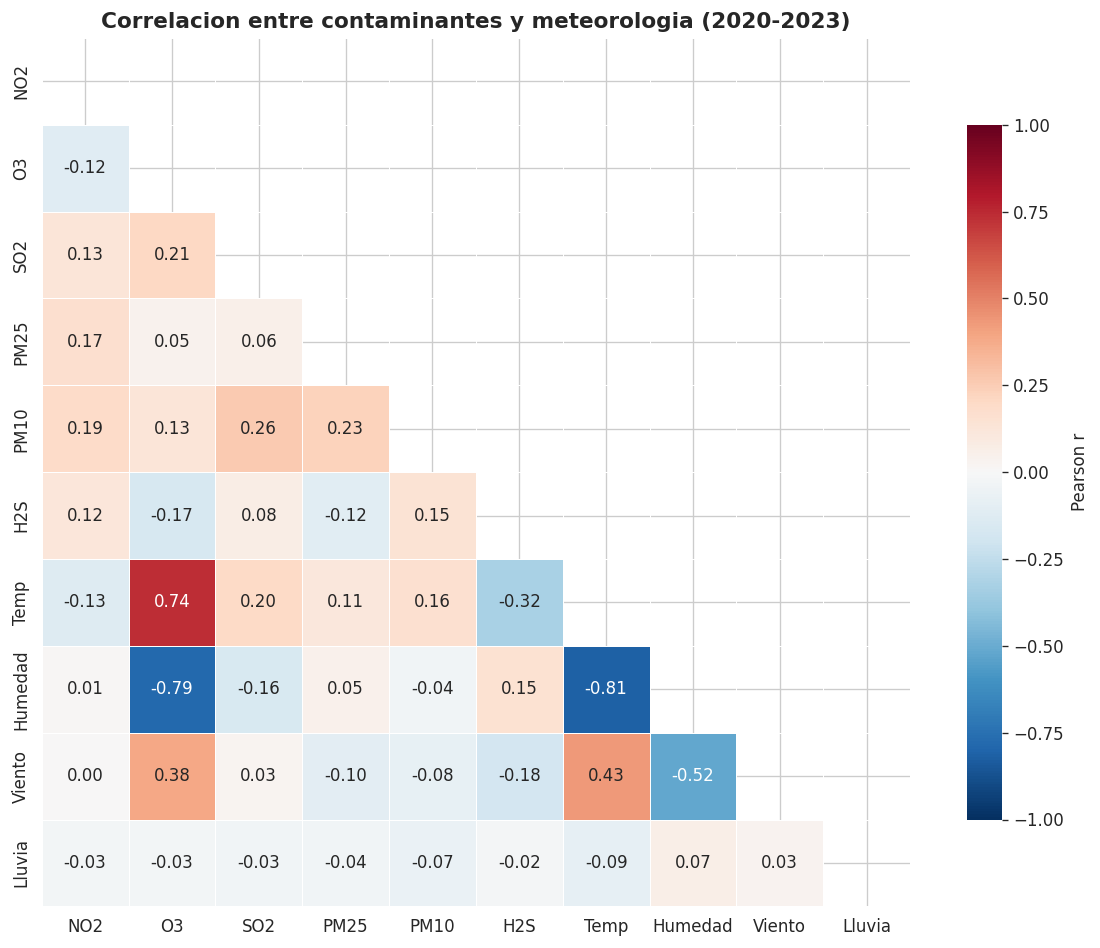

In [9]:
# Seleccionar variables para correlacion
corr_vars = [
    'Univalle_NO2', 'Pance_O3', 'Ermita_SO2', 'Univalle_PM25',
    'Ermita_PM10', 'Flora_H2S', 'Compartir_Temperatura',
    'Pance_Humedad', 'Compartir_Vel_Viento', 'ERA_-_Obrero_Lluvia'
]
labels_short = ['NO2', 'O3', 'SO2', 'PM25', 'PM10', 'H2S',
               'Temp', 'Humedad', 'Viento', 'Lluvia']

corr_matrix = df[corr_vars].corr()
corr_matrix.index = labels_short
corr_matrix.columns = labels_short

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Correlacion entre contaminantes y meteorologia (2020-2023)',
             fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

### Interpretacion de la matriz de correlacion

- **NO2 vs O3:** Correlacion negativa fuerte (tipico: el NO consume O3).
- **O3 vs Temperatura:** Correlacion positiva (mas calor = mas fotoquimica).
- **PM25 vs PM10:** Correlacion positiva alta (comparten fuentes).
- **Humedad vs O3:** Correlacion negativa (nubes reducen radiacion).
- **Viento vs Contaminantes:** Correlacion negativa debil (viento dispersa contaminantes).
- **Lluvia vs PM:** Correlacion negativa (lluvia limpia el aire).

---
## 7. Distribuciones — Histogramas
Distribucion de frecuencias de cada contaminante.

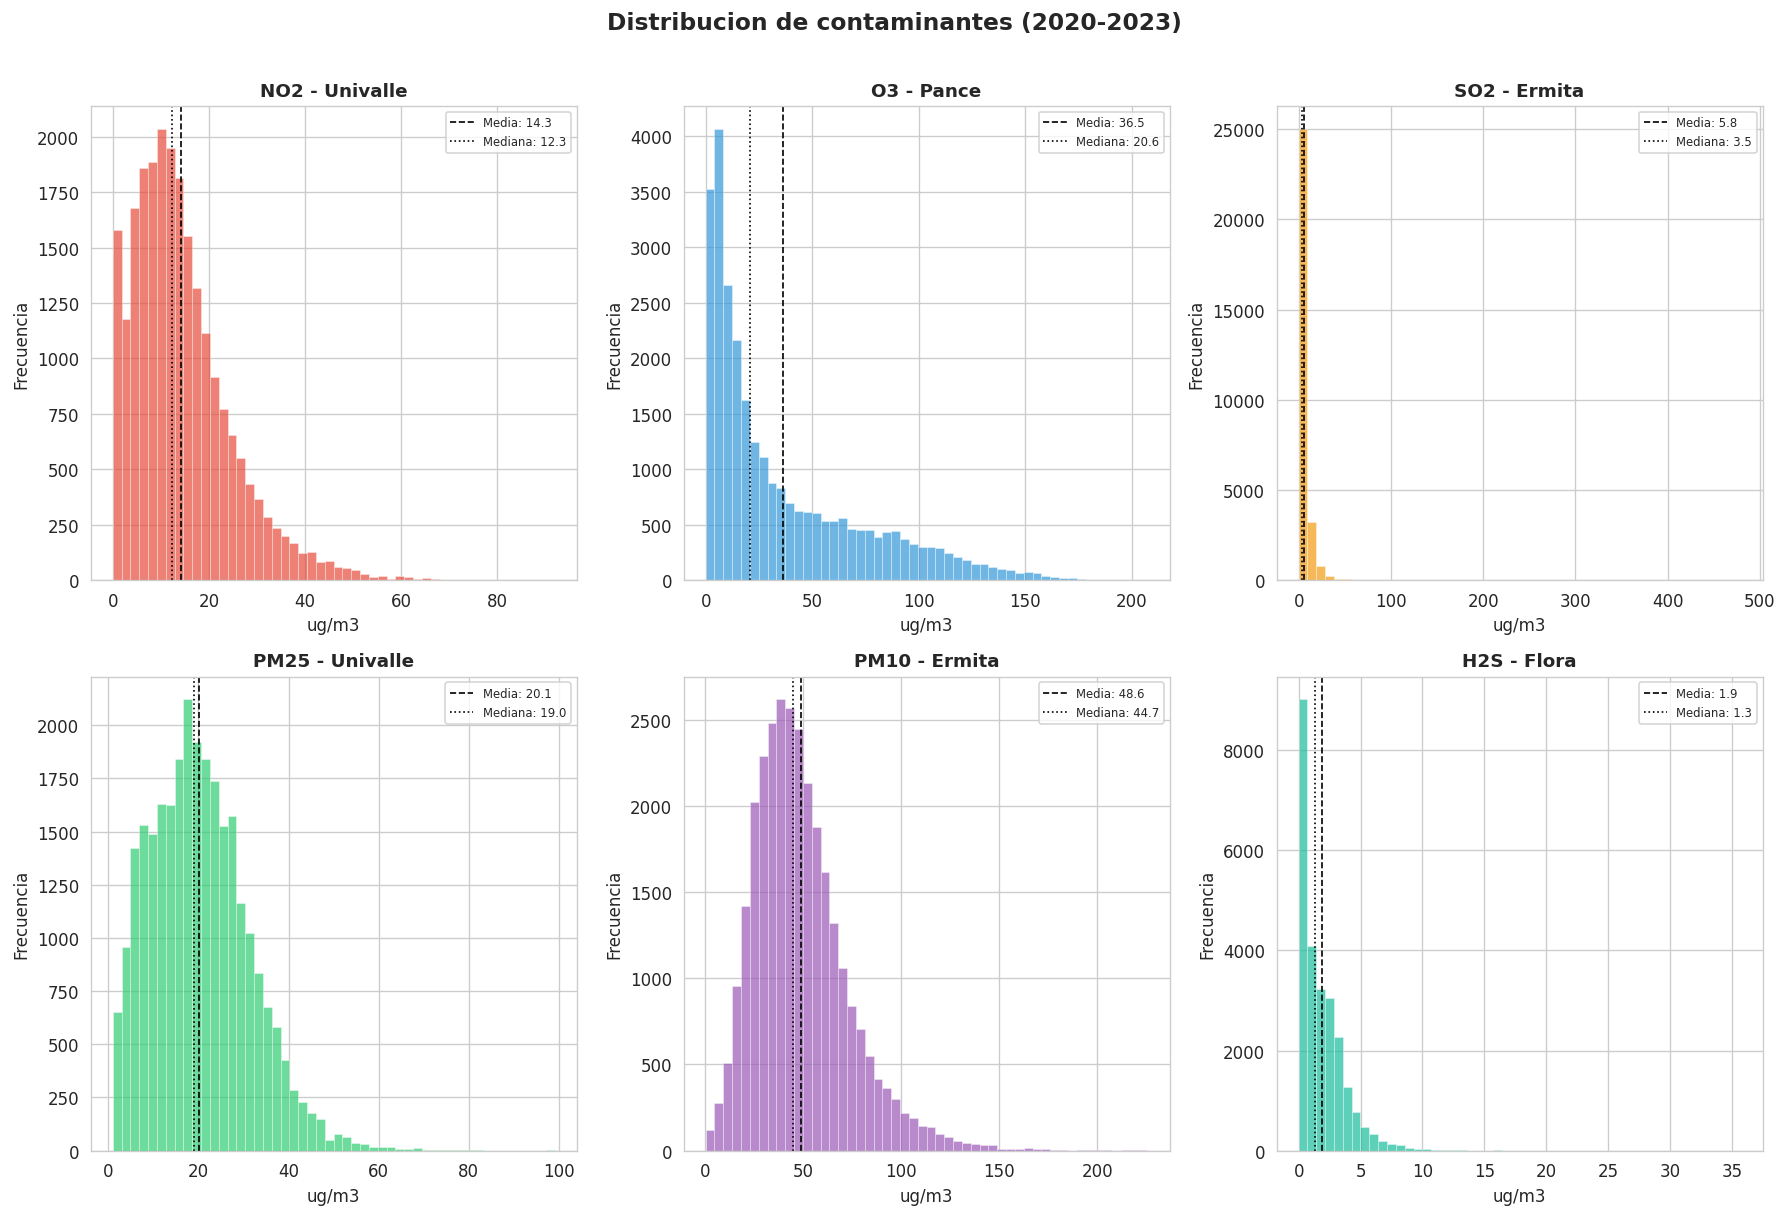

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

dist_vars = [
    ('Univalle_NO2', 'NO2 - Univalle', '#e74c3c'),
    ('Pance_O3', 'O3 - Pance', '#3498db'),
    ('Ermita_SO2', 'SO2 - Ermita', '#f39c12'),
    ('Univalle_PM25', 'PM25 - Univalle', '#2ecc71'),
    ('Ermita_PM10', 'PM10 - Ermita', '#9b59b6'),
    ('Flora_H2S', 'H2S - Flora', '#1abc9c'),
]

for ax, (col, label, color) in zip(axes, dist_vars):
    data = df[col].dropna()
    ax.hist(data, bins=50, color=color, alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1,
               label=f'Media: {data.mean():.1f}')
    ax.axvline(data.median(), color='black', linestyle=':', linewidth=1,
               label=f'Mediana: {data.median():.1f}')
    ax.set_title(label, fontsize=11, weight='bold')
    ax.set_xlabel('ug/m3')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=7)

plt.suptitle('Distribucion de contaminantes (2020-2023)', fontsize=14, weight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Interpretacion de distribuciones
- **NO2:** Distribucion aproximadamente normal centrada en ~14 ug/m3, con cola derecha (episodios altos).
- **O3:** Distribucion sesgada con pico en ~20 ug/m3 y cola derecha hasta ~80 ug/m3.
- **SO2:** Mayor concentracion de valores cerca de 0-10 ug/m3 con algunos episodios altos.
- **PM25 y PM10:** Distribuciones sesgadas a la derecha (tipico de particulas).
- **H2S:** Concentraciones bajas con algunos episodios de olor.

---
## 8. Comparacion interanual
Promedio anual de cada contaminante, 2020 vs 2021 vs 2022 vs 2023.

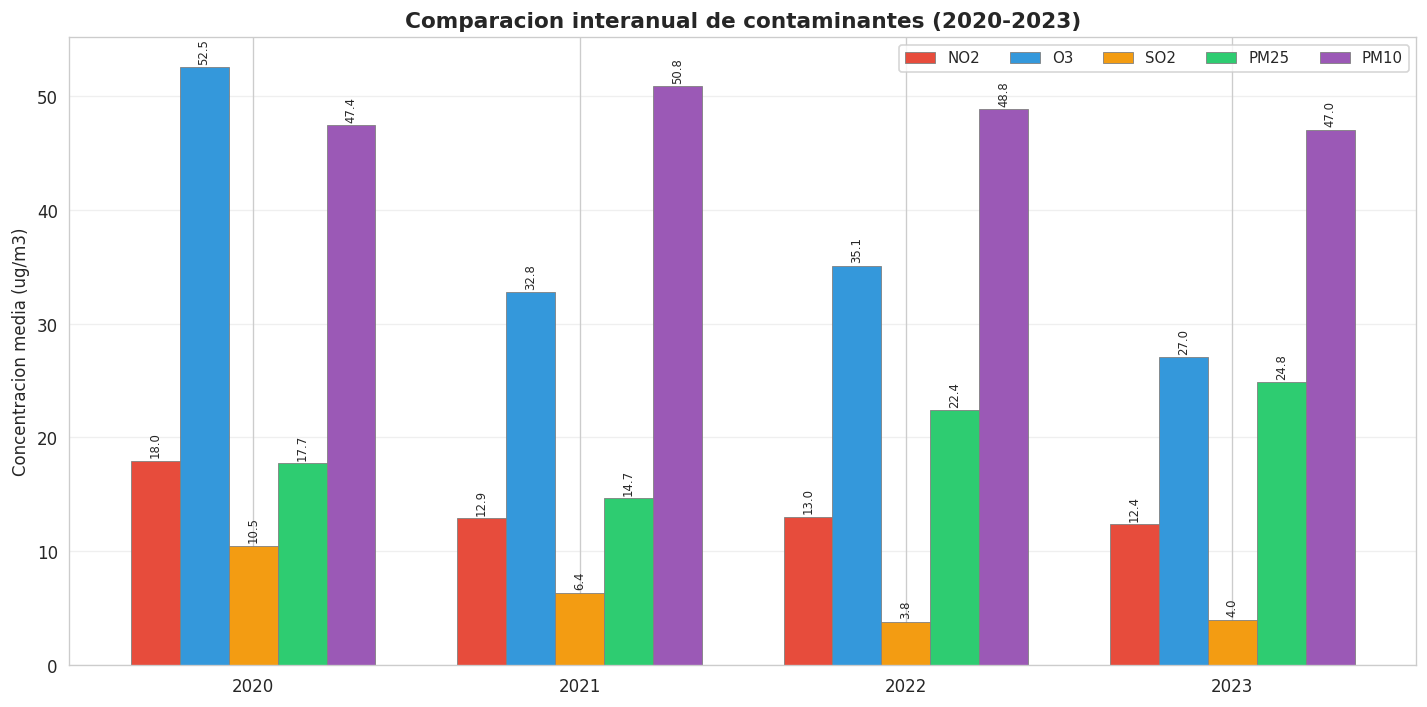

In [11]:
annual = df.groupby('year').agg({
    'Univalle_NO2': 'mean',
    'Pance_O3': 'mean',
    'Ermita_SO2': 'mean',
    'Univalle_PM25': 'mean',
    'Ermita_PM10': 'mean',
}).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

pollutants_annual = {
    'NO2': 'Univalle_NO2',
    'O3': 'Pance_O3',
    'SO2': 'Ermita_SO2',
    'PM25': 'Univalle_PM25',
    'PM10': 'Ermita_PM10',
}

x = np.arange(len(annual))
width = 0.15
colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71', '#9b59b6']

for i, ((label, col), color) in enumerate(zip(pollutants_annual.items(), colors)):
    offset = (i - len(pollutants_annual)/2 + 0.5) * width
    bars = ax.bar(x + offset, annual[col], width, color=color,
                  label=label, edgecolor='gray', linewidth=0.5)
    # Anotar valores
    for bar, val in zip(bars, annual[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(annual['year'])
ax.set_ylabel('Concentracion media (ug/m3)')
ax.set_title('Comparacion interanual de contaminantes (2020-2023)',
             fontsize=13, weight='bold')
ax.legend(fontsize=9, ncol=5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretacion de tendencias interanuales
- **2020:** Menores niveles de NO2 y PM probablemente por la reduccion de movilidad durante la pandemia.
- **2021-2022:** Recuperacion progresiva de los niveles pre-pandemia.
- **2023:** Algunos contaminantes muestran los valores mas altos del periodo.
- **O3:** Se mantiene relativamente estable, con leve tendencia al alza (consistente con el calentamiento global).

---
## 9. Episodios extremos
Deteccion de outliers: valores por encima del percentil 99 para cada contaminante.

Total de episodios extremos (>P99): 1366
(Cada contaminante aporta ~1% de sus registros)



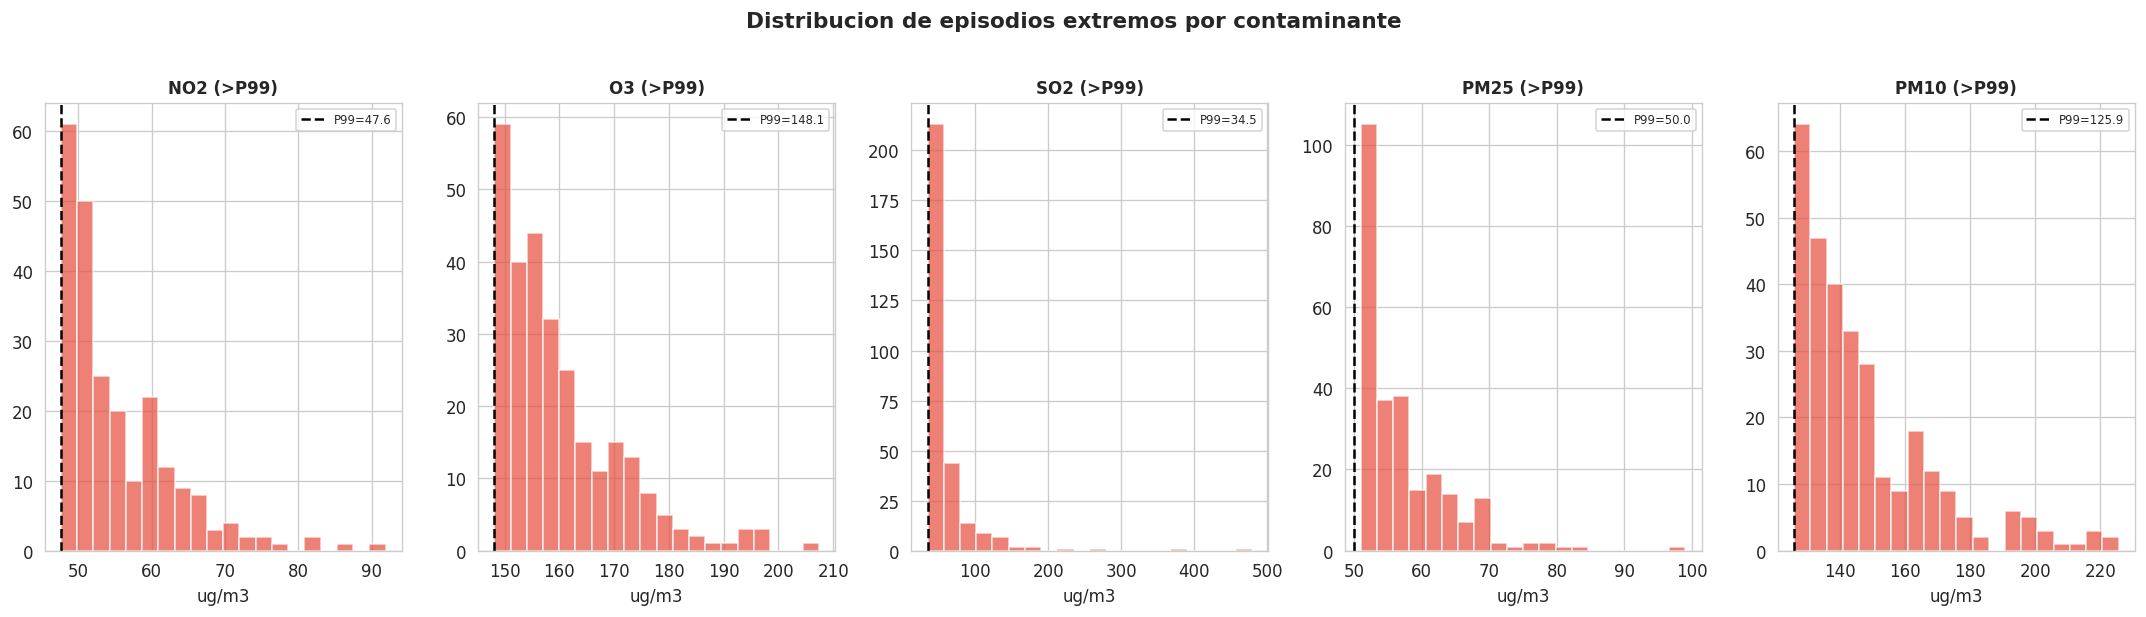


--- Top 5 episodios mas extremos ---

NO2 (max: 91.9 ug/m3):
  2023-06-03 12:00:00: 91.9
  2020-09-13 09:00:00: 85.7
  2020-12-16 14:00:00: 82.5
  2020-06-01 09:00:00: 81.2
  2020-08-20 09:00:00: 76.9

O3 (max: 207.4 ug/m3):
  2020-05-19 15:00:00: 207.4
  2020-09-16 15:00:00: 198.3
  2020-09-07 16:00:00: 197.0
  2022-12-13 17:00:00: 196.0
  2020-10-20 14:00:00: 193.8

SO2 (max: 479.0 ug/m3):
  2021-01-07 14:00:00: 479.0
  2021-01-19 08:00:00: 379.9
  2021-04-23 09:00:00: 276.5
  2021-05-03 08:00:00: 212.6
  2020-10-20 08:00:00: 187.9

PM25 (max: 99.0 ug/m3):
  2023-05-03 11:00:00: 99.0
  2022-08-06 23:00:00: 83.0
  2023-08-11 12:00:00: 81.0
  2022-08-07 03:00:00: 78.0
  2022-08-07 04:00:00: 78.0

PM10 (max: 225.6 ug/m3):
  2021-10-08 08:00:00: 225.6
  2021-10-07 07:00:00: 221.3
  2021-10-05 08:00:00: 219.7
  2021-11-10 09:00:00: 218.7
  2021-11-22 07:00:00: 216.7


In [12]:
extreme_vars = {
    'Univalle_NO2': 'NO2',
    'Pance_O3': 'O3',
    'Ermita_SO2': 'SO2',
    'Univalle_PM25': 'PM25',
    'Ermita_PM10': 'PM10',
}

extremes = []
for col, label in extreme_vars.items():
    p99 = df[col].quantile(0.99)
    p95 = df[col].quantile(0.95)
    extreme = df[df[col] > p99][['Fecha_Hora', col]].copy()
    extreme['contaminante'] = label
    extreme['percentil'] = '>P99'
    extremes.append(extreme)

df_extremes = pd.concat(extremes, ignore_index=True)

print(f'Total de episodios extremos (>P99): {len(df_extremes)}')
print(f'(Cada contaminante aporta ~1% de sus registros)\n')

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, (col, label) in zip(axes, extreme_vars.items()):
    data = df_extremes[df_extremes['contaminante'] == label]
    if len(data) > 0:
        ax.hist(data[col], bins=20, alpha=0.7, color='#e74c3c', edgecolor='white')
        ax.axvline(df[col].quantile(0.99), color='black', linestyle='--',
                   label=f'P99={df[col].quantile(0.99):.1f}')
    ax.set_title(f'{label} (>P99)', fontsize=10, weight='bold')
    ax.set_xlabel('ug/m3')
    ax.legend(fontsize=7)

plt.suptitle('Distribucion de episodios extremos por contaminante',
             fontsize=13, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Mostrar los 5 episodios mas extremos de cada contaminante
print('\n--- Top 5 episodios mas extremos ---')
for col, label in extreme_vars.items():
    top5 = df.nlargest(5, col)[['Fecha_Hora', col]]
    print(f'\n{label} (max: {df[col].max():.1f} ug/m3):')
    for _, row in top5.iterrows():
        print(f'  {row["Fecha_Hora"]}: {row[col]:.1f}')

### Interpretacion de episodios extremos
Los episodios de alta contaminacion pueden estar asociados a condiciones meteorologicas especificas
(inversiones termicas, bajo viento, epoca seca) o a eventos puntuales (incendios, paros de transporte).
Su identificacion permite contextualizar los picos en las series temporales.

---
## 10. Relacion contaminacion-meteorologia
Scatter plots que muestran como las condiciones meteorologicas afectan los contaminantes.

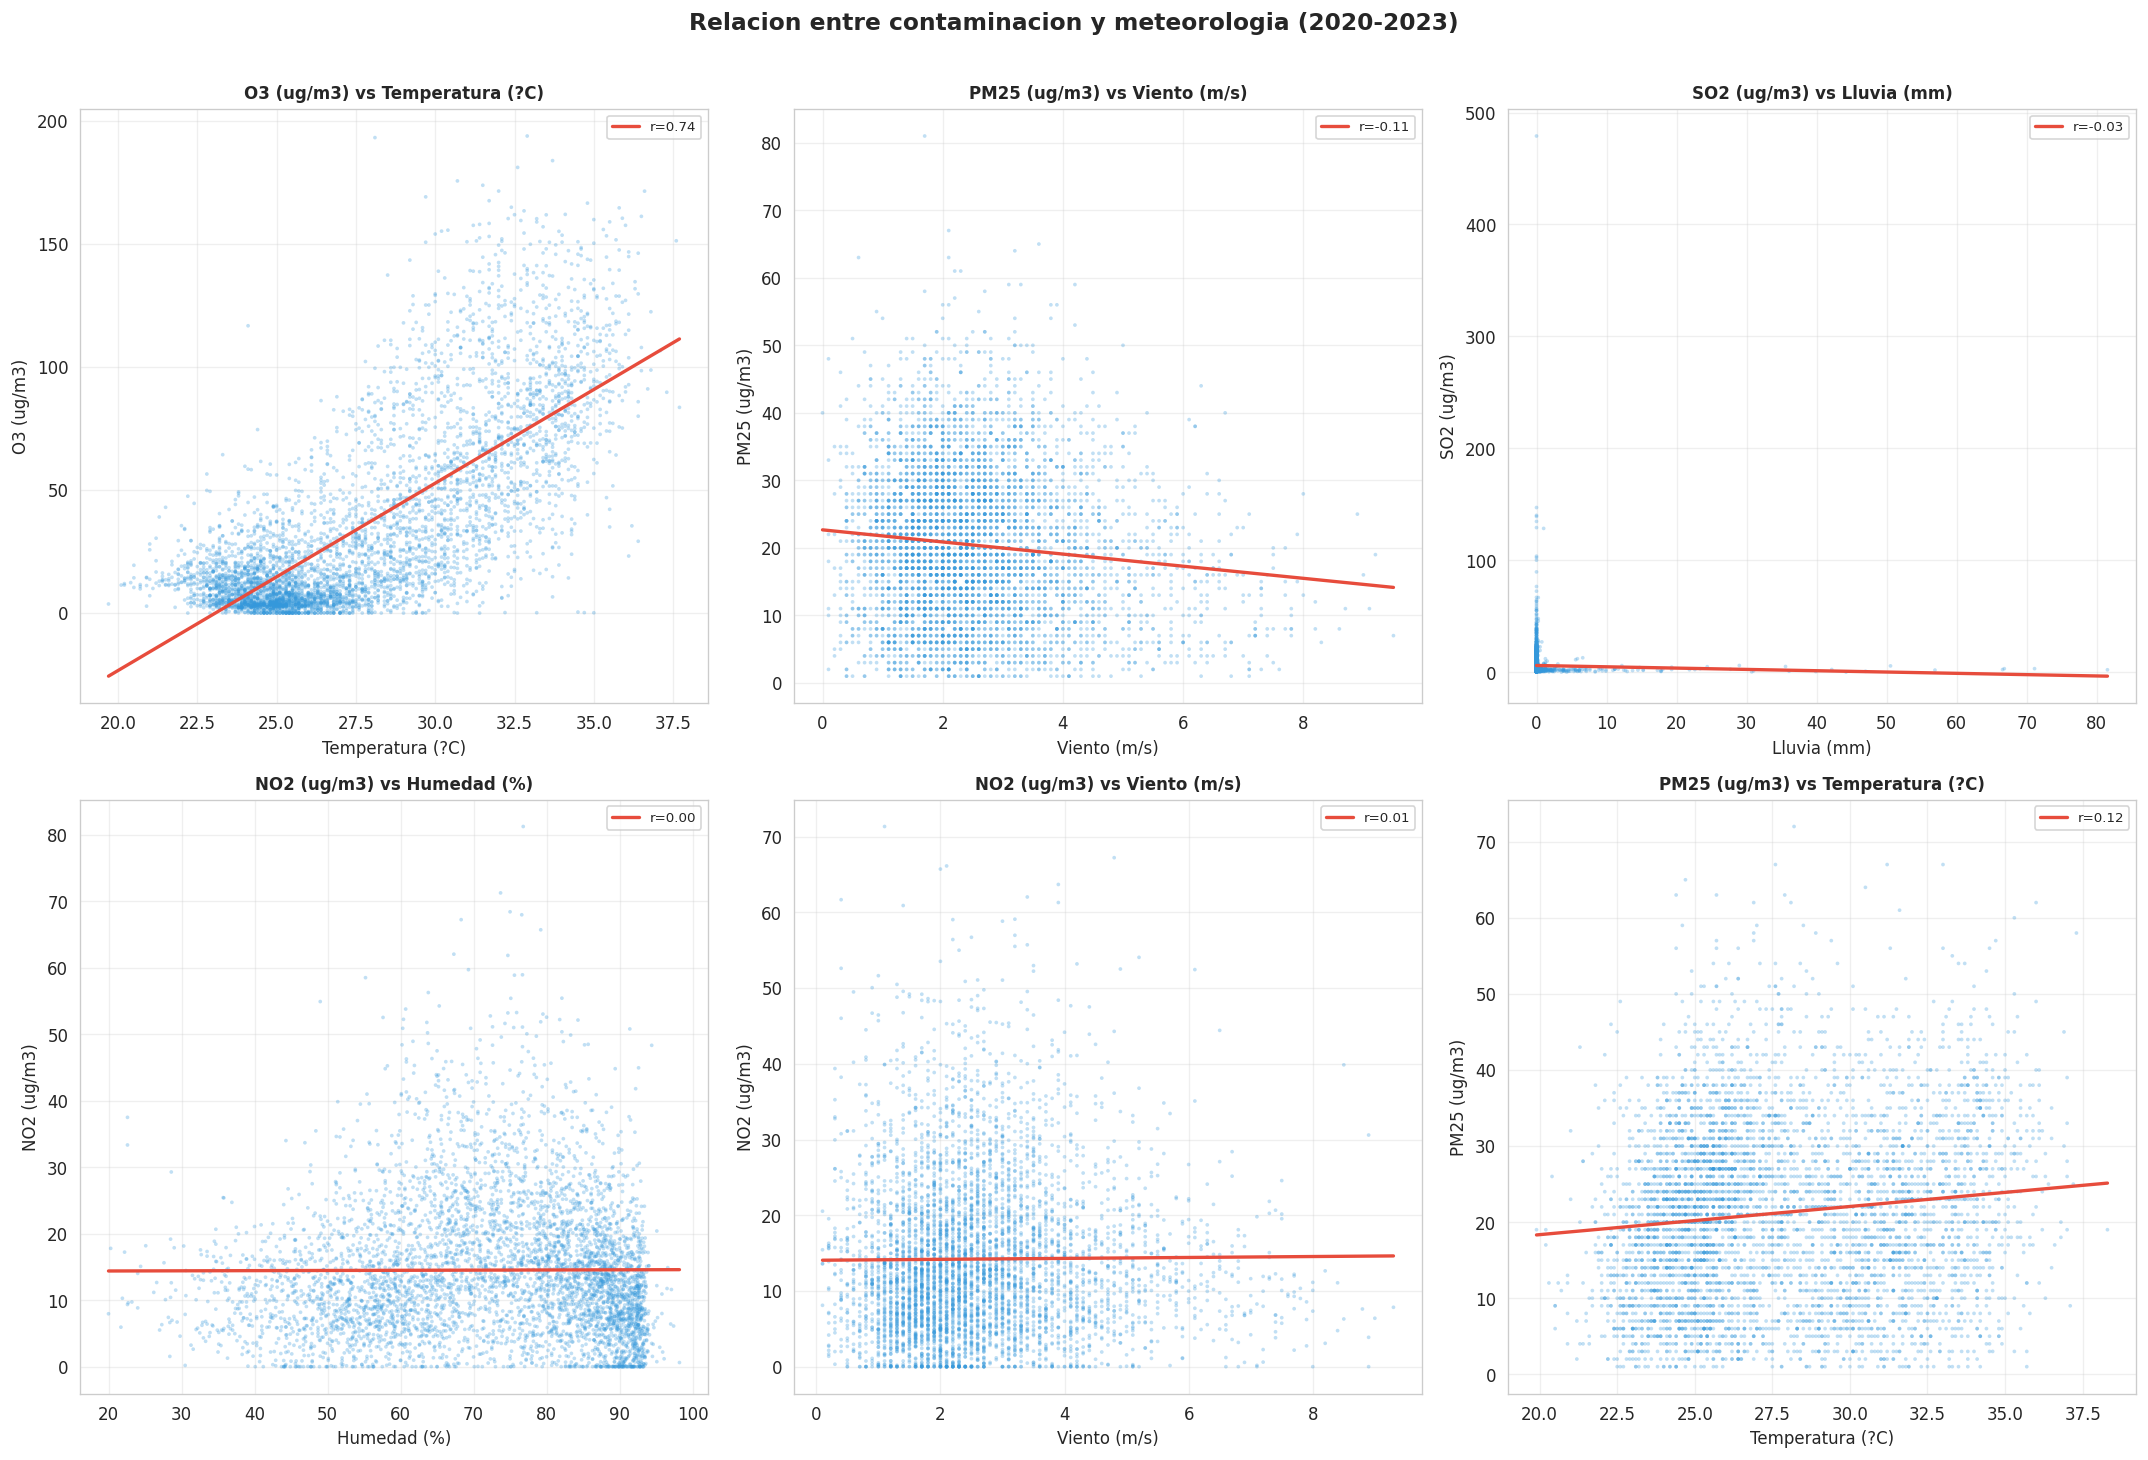

In [13]:
# Definir relaciones a explorar
scatter_pairs = [
    ('Compartir_Temperatura', 'Pance_O3', 'Temperatura (?C)', 'O3 (ug/m3)'),
    ('Compartir_Vel_Viento', 'Univalle_PM25', 'Viento (m/s)', 'PM25 (ug/m3)'),
    ('ERA_-_Obrero_Lluvia', 'Ermita_SO2', 'Lluvia (mm)', 'SO2 (ug/m3)'),
    ('Pance_Humedad', 'Univalle_NO2', 'Humedad (%)', 'NO2 (ug/m3)'),
    ('Compartir_Vel_Viento', 'Univalle_NO2', 'Viento (m/s)', 'NO2 (ug/m3)'),
    ('Compartir_Temperatura', 'Univalle_PM25', 'Temperatura (?C)', 'PM25 (ug/m3)'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, (xcol, ycol, xlabel, ylabel) in zip(axes, scatter_pairs):
    data = df[[xcol, ycol]].dropna().sample(min(5000, len(df)), random_state=42)
    ax.scatter(data[xcol], data[ycol], alpha=0.3, s=5, c='#3498db', edgecolors='none')

    # Linea de tendencia
    if len(data) > 10:
        z = np.polyfit(data[xcol], data[ycol], 1)
        p = np.poly1d(z)
        x_sorted = np.sort(data[xcol])
        ax.plot(x_sorted, p(x_sorted), color='#e74c3c', linewidth=2,
                label=f'r={data[xcol].corr(data[ycol]):.2f}')

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} vs {xlabel}', fontsize=10, weight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Relacion entre contaminacion y meteorologia (2020-2023)',
             fontsize=14, weight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Interpretacion de relaciones contaminacion-meteo

- **Temp vs O3:** Relacion positiva clara — a mayor temperatura, mayor formacion fotoquimica de ozono.
- **Viento vs PM25:** Relacion negativa — el viento dispersa las particulas.
- **Lluvia vs SO2:** Relacion negativa debil — la lluvia elimina SO2 por deposicion humeda.
- **Humedad vs NO2:** Relacion negativa — mayor humedad (nubes) reduce la fotoquimica y dispersa contaminantes.
- **Viento vs NO2:** Negativa — el viento dispersa NO2.
- **Temp vs PM25:** Positiva debil — mayor temperatura puede resuspender particulas en epoca seca.

---
## 11. Export: Promedios mensuales para ERA5
Genera `dagma_monthly_means.csv` con columnas: date, NO2, SO2, O3, PM25, PM10
Una fila por mes, promedio de todas las estaciones disponibles.

In [14]:
# Columnas a exportar (usar la estacion con mejor cobertura para cada contaminante)
export_cols = {
    'NO2': 'Univalle_NO2',
    'SO2': 'Ermita_SO2',
    'O3': 'Pance_O3',
    'PM25': 'Univalle_PM25',
    'PM10': 'Ermita_PM10',
}

# Promedio mensual
monthly_export = df.groupby(['year', 'month']).agg({
    **{v: 'mean' for v in export_cols.values()}
}).reset_index()
monthly_export['date'] = pd.to_datetime(
    monthly_export[['year', 'month']].assign(day=1))
monthly_export = monthly_export.sort_values('date')

# Renombrar y seleccionar columnas
monthly_export = monthly_export.rename(columns={
    v: k for k, v in export_cols.items()
})
monthly_export = monthly_export[['date'] + list(export_cols.keys())]

from pathlib import Path
# Guardar
salida ='dagma_monthly_means.csv'
monthly_export.to_csv(salida, index=False)

print(f'Exportado: {salida}')
print(f'Meses: {len(monthly_export)} ({monthly_export["date"].min().strftime("%Y-%m")} '
      f'a {monthly_export["date"].max().strftime("%Y-%m")})')
print(f'\nEstadisticos:')
display(monthly_export.describe().round(2))


Exportado: dagma_monthly_means.csv
Meses: 48 (2020-01 a 2023-12)

Estadisticos:


,date,NO2,SO2,O3,PM25,PM10
count,48,43.00,45.00,47.00,48.00,47.00
mean,2021-12-15 23:00:00,13.62,5.86,36.80,19.53,48.38
min,2020-01-01 00:00:00,0.00,2.59,16.58,6.88,37.49
25%,2020-12-24 06:00:00,10.60,3.72,29.00,16.72,44.81
50%,2021-12-16 12:00:00,13.44,4.83,34.43,18.85,47.57
75%,2022-12-08 18:00:00,15.89,6.66,45.08,23.15,50.35
max,2023-12-01 00:00:00,21.70,19.17,65.88,31.39,66.85
std,NaN,4.37,3.49,11.53,5.70,5.65


---
### Resumen del EDA SVCASC

| # | Visualizacion | Descripcion |
|---|--------------|-------------|
| 1 | Heatmap de cobertura | % datos disponibles por estacion y variable |
| 2 | Series temporales | 12 meses de contaminantes y meteorologia |
| 3 | Boxplots mensuales | Ciclo estacional de 6 variables |
| 4 | Ciclo diurno | Comportamiento horario de contaminantes y meteo |
| 5 | Mapa (Folium) | Estaciones SVCASC con NO2 |
| 6 | Matriz de correlacion | Relaciones entre 10 variables |
| 7 | Histogramas | Distribucion de 6 contaminantes |
| 8 | Barras interanuales | 2020 vs 2021 vs 2022 vs 2023 |
| 9 | Episodios extremos | Outliers >P99 por contaminante |
| 10 | Scatter plots | Contaminacion vs meteorologia |
| **Export** | dagma_monthly_means.csv | Promedios mensuales para ERA5 |

### Hallazgos principales

- NO2 solo disponible en estacion Univalle (69% cobertura). Las demas estaciones no tienen NO2.
- O3, SO2, PM25, PM10 tienen buena cobertura en multiples estaciones.
- Los datos meteorologicos permiten analizar relaciones causales con la contaminacion.
- Se detecto el efecto COVID-19 en 2020 (menores niveles de NO2 y PM).
- El O3 muestra correlacion positiva con temperatura y negativa con humedad (tipico).
- Los periodos secos (diciembre-marzo) concentran los niveles mas altos de PM.